# Validate and explore the published synthetic lending dataset
By Wael El Ghazzawi. Developed with OpenAI Codex assistance.

This companion reads the published CSV files instead of regenerating them. It checks their relationship, summarizes the latest observations, and compares payment scenarios. All records and USD amounts are fictional. Scenario labels are generator settings, not real borrower risk grades; scheduled principal is not an accounting balance. This is a data-analysis exercise, not a risk model.

Dataset: https://www.kaggle.com/datasets/waelelghazzawi/synthetic-lending-portfolio-and-monthly-payments

Generator and utility source: https://github.com/identity-wael/synthetic-lending-playbook

License: Apache-2.0 for this notebook; source dataset CC0-1.0.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = Path('/kaggle/input') if Path('/kaggle/input').exists() else Path.cwd() / 'synthetic_lending'
candidates = list(root.rglob('loans.csv'))
assert len(candidates) == 1, f'Attach the synthetic lending dataset; found {len(candidates)} loans.csv files'
folder = candidates[0].parent
loans = pd.read_csv(folder / 'loans.csv', parse_dates=['origination_date'])
monthly = pd.read_csv(folder / 'monthly_performance.csv', parse_dates=['observation_date', 'oldest_unpaid_due_date'])
manifest = json.loads((folder / 'manifest.json').read_text())
assert manifest['synthetic'] is True
assert len(loans) == manifest['loan_count']
assert len(monthly) == manifest['monthly_rows']
assert loans.loan_id.is_unique
assert not monthly.duplicated(['loan_id', 'observation_date']).any()
assert set(monthly.loan_id) == set(loans.loan_id)
print(f'PASS: {len(loans):,} fictional contracts and {len(monthly):,} monthly observations')

PASS: 1,500 fictional contracts and 22,743 monthly observations


## Latest snapshot and denominators
Select one observation per loan at the dataset cutoff. Rates below are counts of accounts, not dollar-weighted exposure or actual principal at risk. Loans with no observations at this cutoff would be excluded explicitly; in this release every loan is present.

,accounts,overdue_30_plus,overdue_share
segment,,,
Scenario A,668,5,0.007485
Scenario B,542,33,0.060886
Scenario C,290,45,0.155172


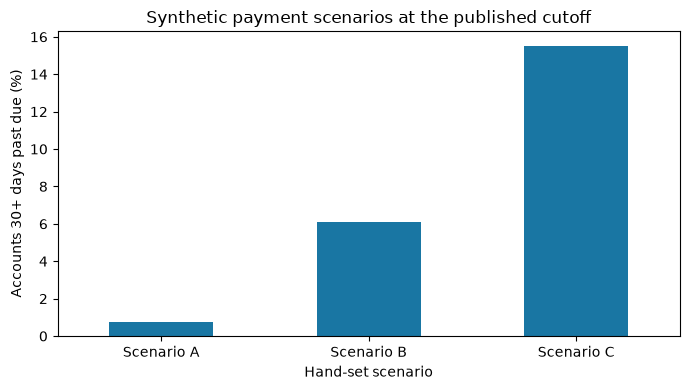

In [2]:
cutoff = pd.Timestamp(manifest['cutoff'])
snapshot = monthly.loc[monthly.observation_date.eq(cutoff)].merge(loans, on='loan_id', validate='one_to_one')
assert len(snapshot) == len(loans)
snapshot['dpd30_plus'] = snapshot.dpd.ge(30)
summary = snapshot.groupby('segment').agg(accounts=('loan_id', 'size'), overdue_30_plus=('dpd30_plus', 'sum'))
summary['overdue_share'] = summary.overdue_30_plus / summary.accounts
assert summary.accounts.sum() == len(loans)
display(summary)
ax = summary.overdue_share.mul(100).plot.bar(color='#1976A3', figsize=(7, 4))
ax.set(title='Synthetic payment scenarios at the published cutoff', ylabel='Accounts 30+ days past due (%)', xlabel='Hand-set scenario')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Calendar sanity check
An installment due today is not yet days past due. Empty queues are represented by a missing oldest-unpaid date. Calendar differences—not a fixed 30-day multiplier—determine DPD.

In [3]:
expected = (monthly.observation_date - monthly.oldest_unpaid_due_date).dt.days.fillna(0)
assert expected.eq(monthly.dpd).all()
assert monthly.oldest_unpaid_due_date.isna().eq(monthly.unpaid_installments.eq(0)).all()
print('PASS: calendar DPD and missing-date semantics verified')
print('Try comparing account rates with a scheduled-principal-weighted teaching proxy; explain why neither validates real lending risk.')

PASS: calendar DPD and missing-date semantics verified
Try comparing account rates with a scheduled-principal-weighted teaching proxy; explain why neither validates real lending risk.
